# 15-2: Repaso — Regresión Logística y Modelos de Conteo

**Curso:** Modelos de Análisis Estadístico (MAE) — Universidad de los Andes  
**Docente:** Prof. Alejandra Tabares  
**Semana:** 15 — Repaso Final

## 1. Regresión Logística — Resumen

### Modelo

$$
\text{logit}(\pi_i) = \ln\!\left(\frac{\pi_i}{1-\pi_i}\right) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}
$$

$$
\pi_i = P(Y_i = 1 \mid \mathbf{x}_i) = \frac{e^{\mathbf{x}_i^\top \boldsymbol{\beta}}}{1 + e^{\mathbf{x}_i^\top \boldsymbol{\beta}}} = \frac{1}{1 + e^{-\mathbf{x}_i^\top \boldsymbol{\beta}}}
$$

### ¿Por Qué No Usar MCO para Resultados Binarios?

El modelo de probabilidad lineal (MPL) con MCO puede predecir $\hat{\pi} < 0$ o $\hat{\pi} > 1$, y la varianza del error es heteroscedástica. El enlace logit restringe las predicciones al intervalo $(0,1)$.

### Interpretación — Tres Escalas

| Escala | Expresión | Interpretación de $\beta_j$ |
|---|---|---|
| **Log-momios** (logit) | $\mathbf{x}^\top\boldsymbol{\beta}$ | Aditivo: $\beta_j$ = cambio en log-momios por unidad de $x_j$ |
| **Razón de momios** | $e^{\beta_j}$ | Multiplicativo: RM = factor por el que cambian los momios por unidad de $x_j$ |
| **Probabilidad** | $1/(1+e^{-\mathbf{x}^\top\boldsymbol{\beta}})$ | No lineal; depende de los valores de todas las $x$ |

### Estimación — Máxima Verosimilitud

La log-verosimilitud para $n$ observaciones binarias:

$$
\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \ln \pi_i + (1-y_i) \ln(1-\pi_i) \right]
$$

Sin solución en forma cerrada; se resuelve iterativamente mediante **IRLS** (Mínimos Cuadrados Iterativamente Reponderados).

### Evaluación del Modelo

| Métrica | Qué mide |
|---|---|
| **Devianza** | $-2\ell(\hat{\boldsymbol{\beta}})$; menor es mejor |
| **AIC** | $-2\ell + 2p$ |
| **$R^2$ de McFadden** | $1 - \ell(\hat{\boldsymbol{\beta}})/\ell(\boldsymbol{\beta}_0)$ |
| **Matriz de confusión** | Exactitud, sensibilidad (recall), especificidad, VPP |
| **AUC-ROC** | Probabilidad de que el modelo clasifique un positivo aleatorio por encima de un negativo aleatorio; 0.5 = aleatorio, 1.0 = perfecto |

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2025)
n = 400

# Simular resultado binario: disease = 1
age     = np.random.normal(55, 12, n)
bmi     = np.random.normal(27, 5, n)
smoking = np.random.binomial(1, 0.3, n)

# Logit verdadero: log-momios = -6 + 0.06*age + 0.08*bmi + 1.2*smoking
logit_true = -6 + 0.06 * age + 0.08 * bmi + 1.2 * smoking
pi_true    = 1 / (1 + np.exp(-logit_true))
disease    = np.random.binomial(1, pi_true, n)

df = pd.DataFrame({'disease': disease, 'age': age, 'bmi': bmi, 'smoking': smoking})

print('Conjunto de datos simulado: disease ~ age + bmi + smoking')
print(f'Prevalencia del resultado: {disease.mean():.3f} ({disease.sum()} casos de {n})')
print(df.head(8).round(2).to_string(index=False))

Conjunto de datos simulado: disease ~ age + bmi + smoking
Prevalencia del resultado: 0.485 (194 casos de 400)
 disease   age   bmi  smoking
       0 53.89 29.12        0
       0 63.81 27.11        1
       1 37.73 30.59        0
       0 47.04 26.13        0
       0 53.79 29.98        0
       1 80.76 27.51        0
       0 71.72 30.76        0
       0 52.51 20.62        1


In [2]:
# ── Ajustar regresión logística ────────────────────────────────────────────────────────

logit_model = smf.logit('disease ~ age + bmi + smoking', data=df).fit()
print(logit_model.summary())

# Razones de momios con IC 95%
or_table = pd.DataFrame({
    'OR':       np.exp(logit_model.params),
    'OR_lower': np.exp(logit_model.conf_int()[0]),
    'OR_upper': np.exp(logit_model.conf_int()[1]),
    'p-value':  logit_model.pvalues
}).round(4)

print('\nTabla de Razones de Momios (IC 95%)')
print('='*55)
print(or_table.to_string())

print('\nEjemplo de interpretación:')
or_smoking = np.exp(logit_model.params['smoking'])
print(f'  RM tabaquismo = {or_smoking:.3f}: los fumadores tienen {or_smoking:.2f} veces los momios')
print('  de enfermedad en comparación con los no fumadores, manteniendo edad e IMC constantes.')

Optimization terminated successfully.
         Current function value: 0.590787
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                disease   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.1471
Time:                        17:25:13   Log-Likelihood:                -236.31
converged:                       True   LL-Null:                       -277.08
Covariance Type:            nonrobust   LLR p-value:                 1.443e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.1482      0.925     -6.644      0.000      -7.962      -4.335
age            0.0530      0.

Resumen de la Matriz de Confusión (umbral = 0.5)
  Verdaderos Positivos  (VP): 125
  Verdaderos Negativos  (VN): 147
  Falsos Positivos      (FP): 59
  Falsos Negativos      (FN): 69
  Exactitud:                  0.680
  Sensibilidad (Recall):      0.644
  Especificidad:              0.714
  VPP (Precisión):            0.679
  AUC-ROC:                    0.747


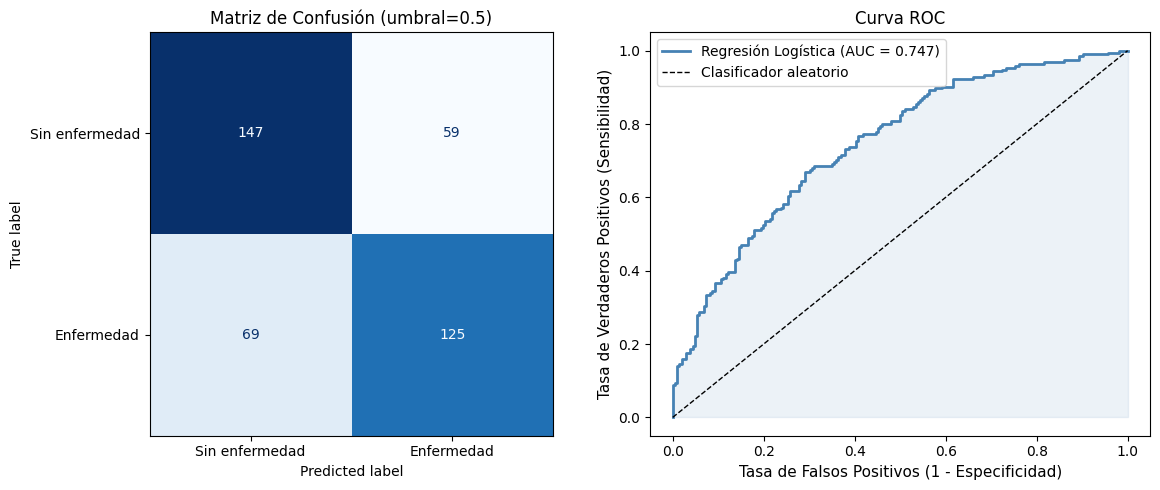

In [3]:
# ── Matriz de confusión y curva ROC ───────────────────────────────────────────────────

y_pred_prob = logit_model.predict(df)
threshold   = 0.5
y_pred      = (y_pred_prob >= threshold).astype(int)
y_true      = df['disease'].values

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
accuracy    = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # recall
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)  # precision
auc         = roc_auc_score(y_true, y_pred_prob)

print('Resumen de la Matriz de Confusión (umbral = 0.5)')
print('='*45)
print(f'  Verdaderos Positivos  (VP): {tp}')
print(f'  Verdaderos Negativos  (VN): {tn}')
print(f'  Falsos Positivos      (FP): {fp}')
print(f'  Falsos Negativos      (FN): {fn}')
print(f'  Exactitud:                  {accuracy:.3f}')
print(f'  Sensibilidad (Recall):      {sensitivity:.3f}')
print(f'  Especificidad:              {specificity:.3f}')
print(f'  VPP (Precisión):            {ppv:.3f}')
print(f'  AUC-ROC:                    {auc:.3f}')

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mapa de calor de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin enfermedad', 'Enfermedad'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión (umbral={threshold})', fontsize=12)

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Regresión Logística (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 2. Regresión de Poisson — Resumen

### Modelo

$$
Y_i \sim \text{Poisson}(\mu_i), \qquad \ln(\mu_i) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}
$$

### Interpretación — Razones de Tasas

$$
e^{\hat{\beta}_j} = \text{Razón de Tasas (RT)}
$$

Por un aumento de una unidad en $x_j$, el conteo esperado es **multiplicado por $e^{\hat{\beta}_j}$**, manteniendo fijos los demás predictores.

### Supuestos Clave

1. **Log-linealidad**: $\ln(\mu)$ es lineal en los predictores
2. **Independencia**: las observaciones son independientes
3. **Equidispersión**: $\text{Var}(Y_i) = E[Y_i] = \mu_i$ (media = varianza)

### Desplazamiento (Offset)

Al modelar **tasas** (conteos por unidad de exposición $t_i$):

$$
\ln(\mu_i / t_i) = \mathbf{x}_i^\top \boldsymbol{\beta} \quad \Longleftrightarrow \quad \ln(\mu_i) = \ln(t_i) + \mathbf{x}_i^\top \boldsymbol{\beta}
$$

El término $\ln(t_i)$ se incluye como **desplazamiento** con coeficiente fijo en 1.

### Sobredispersión

Si $\hat{D}/(n-p-1) \gg 1$ (digamos, $> 1.5$), la varianza supera a la media — **sobredispersión**. Esto infla los estadísticos de prueba y produce intervalos de confianza demasiado estrechos.

**Soluciones:**

| Enfoque | Modelo | Cuándo |
|---|---|---|
| Escalar errores estándar | Quasi-Poisson | Sobredispersión leve |
| Varianza adicional explícita | Binomial Negativa | Sobredispersión moderada-grave |
| Verificar inflación de ceros | Poisson con inflación de ceros / ZINB | Exceso de ceros |

In [4]:
# ── Simular datos de conteo y ajustar Poisson + Binomial Negativa ─────────────────────

np.random.seed(42)
n_cnt = 300

x1 = np.random.normal(0, 1, n_cnt)
x2 = np.random.binomial(1, 0.4, n_cnt)      # covariable binaria
mu_pois = np.exp(1.5 + 0.6 * x1 + 0.8 * x2)

# Conteos sobredispersos: usar Binomial Negativa (dispersión r = 3)
r_nb  = 3.0
p_nb  = r_nb / (r_nb + mu_pois)
y_nb  = np.random.negative_binomial(r_nb, p_nb, n_cnt)

# También generar conteos con distribución Poisson para comparación
y_pois = np.random.poisson(mu_pois, n_cnt)

df_cnt = pd.DataFrame({'y_nb': y_nb, 'y_pois': y_pois, 'x1': x1, 'x2': x2})

print('Resumen del conjunto de datos de conteo')
print(f'  y_nb   — media: {y_nb.mean():.2f}, var: {y_nb.var():.2f},',
      f'var/media = {y_nb.var()/y_nb.mean():.2f}  (sobredisperso si >> 1)')
print(f'  y_pois — media: {y_pois.mean():.2f}, var: {y_pois.var():.2f},',
      f'var/media = {y_pois.var()/y_pois.mean():.2f}  (equidisperso \u2248 1)')

# Poisson en datos sobredispersos
pois_nb  = smf.glm('y_nb ~ x1 + x2', data=df_cnt,
                    family=sm.families.Poisson()).fit()
# Binomial Negativa en datos sobredispersos
nb_model = smf.glm('y_nb ~ x1 + x2', data=df_cnt,
                    family=sm.families.NegativeBinomial()).fit()
# Poisson en datos correctamente distribuidos
pois_ok  = smf.glm('y_pois ~ x1 + x2', data=df_cnt,
                    family=sm.families.Poisson()).fit()

print('\n' + '='*65)
print('GLM Poisson en conteos SOBREDISPERSOS (y_nb)')
print('='*65)
print(pois_nb.summary2().tables[1].to_string())
disp_ratio = pois_nb.deviance / pois_nb.df_resid
print(f'\n  Devianza residual / gl = {disp_ratio:.2f}',
      '\u2192 SOBREDISPERSO (debería ser ~1)' if disp_ratio > 1.5 else '\u2192 OK')

print('\n' + '='*65)
print('GLM Binomial Negativa en conteos SOBREDISPERSOS (y_nb)')
print('='*65)
print(nb_model.summary2().tables[1].to_string())

print('\n' + '='*65)
print('GLM Poisson en conteos EQUIDISPERSOS (y_pois)')
print('='*65)
print(pois_ok.summary2().tables[1].to_string())
disp_ratio_ok = pois_ok.deviance / pois_ok.df_resid
print(f'\n  Devianza residual / gl = {disp_ratio_ok:.2f}',
      '\u2192 SOBREDISPERSO' if disp_ratio_ok > 1.5 else '\u2192 OK (equidisperso)')

Resumen del conjunto de datos de conteo
  y_nb   — media: 6.90, var: 55.51, var/media = 8.04  (sobredisperso si >> 1)
  y_pois — media: 7.66, var: 42.48, var/media = 5.54  (equidisperso ≈ 1)

GLM Poisson en conteos SOBREDISPERSOS (y_nb)
              Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
Intercept  1.387335  0.037267  37.227114  2.486145e-303  1.314293  1.460376
x1         0.608049  0.022007  27.630061  4.845968e-168  0.564917  0.651182
x2         0.804435  0.045564  17.655210   9.278721e-70  0.715132  0.893738

  Devianza residual / gl = 3.24 → SOBREDISPERSO (debería ser ~1)

GLM Binomial Negativa en conteos SOBREDISPERSOS (y_nb)
              Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept  1.402484  0.084513  16.594915  7.585122e-62  1.236842  1.568126
x1         0.604109  0.066306   9.110971  8.164807e-20  0.474153  0.734066
x2         0.777199  0.129542   5.999594  1.978112e-09  0.523301  1.031097

GLM Poisson en conteos EQUIDISPERSOS

In [5]:
# ── Comparación AIC: Poisson vs Binomial Negativa en datos sobredispersos ─────────────

aic_compare = pd.DataFrame({
    'Model':        ['Poisson (en sobredispersos)', 'Binomial Negativa'],
    'AIC':          [pois_nb.aic, nb_model.aic],
    'Deviance':     [pois_nb.deviance, nb_model.deviance],
    'Dev/df':       [pois_nb.deviance/pois_nb.df_resid,
                     nb_model.deviance/nb_model.df_resid]
}).round(3)

print('Comparación AIC: Poisson vs Binomial Negativa')
print('='*60)
print(aic_compare.to_string(index=False))
print('\n  AIC menor = mejor ajuste. BN debería ganar cuando los datos son sobredispersos.')

# Tabla de razones de tasas para el modelo BN
rr_table = pd.DataFrame({
    'RR':       np.exp(nb_model.params),
    'RR_lower': np.exp(nb_model.conf_int()[0]),
    'RR_upper': np.exp(nb_model.conf_int()[1]),
    'p-value':  nb_model.pvalues
}).round(4)
print('\nBinomial Negativa — Tabla de Razones de Tasas (IC 95%)')
print('='*55)
print(rr_table.to_string())

Comparación AIC: Poisson vs Binomial Negativa
                      Model      AIC  Deviance  Dev/df
Poisson (en sobredispersos) 1932.326   963.236   3.243
          Binomial Negativa 1692.149   175.294   0.590

  AIC menor = mejor ajuste. BN debería ganar cuando los datos son sobredispersos.

Binomial Negativa — Tabla de Razones de Tasas (IC 95%)
               RR  RR_lower  RR_upper  p-value
Intercept  4.0653    3.4447    4.7976      0.0
x1         1.8296    1.6067    2.0835      0.0
x2         2.1754    1.6876    2.8041      0.0


## 3. Comparación: MCO vs Logística vs Poisson

| Característica | **MCO (Lineal)** | **Regresión Logística** | **Regresión de Poisson** |
|---|---|---|---|
| **Tipo de respuesta** | Continua, sin límites | Binaria (0/1) o proporción | Entero no negativo (conteo) |
| **Distribución** | Normal ($\mathcal{N}$) | Binomial | Poisson |
| **Función de enlace** | Identidad: $\mu = \mathbf{x}^\top\boldsymbol{\beta}$ | Logit: $\ln(\pi/(1-\pi))$ | Log: $\ln(\mu)$ |
| **Interpretación del coeficiente** | Cambio aditivo en $E[Y]$ | Cambio aditivo en log-momios; $e^\beta$ = RM | Cambio aditivo en $\ln(\mu)$; $e^\beta$ = RT |
| **Estimación** | MCO (forma cerrada) | MV (IRLS) | MV (IRLS) |
| **Supuesto clave** | Errores normales homocedasticos | $Y_i \sim \text{Bernoulli}(\pi_i)$ | $\text{Var}(Y_i) = \mu_i$ (equidispersión) |
| **Bondad de ajuste** | $R^2$, RECM, prueba F | Devianza, AUC, $R^2$ de McFadden | Devianza, devianza / gl, AIC |
| **Sobredispersión** | No aplica (estima $\sigma^2$) | Puede usar quasi-binomial | Usar BN o quasi-Poisson |
| **Predicción** | $\hat{y} \in (-\infty, +\infty)$ | $\hat{\pi} \in (0, 1)$ | $\hat{\mu} \in (0, +\infty)$ |

### Cuándo Usar Cada Modelo

| Situación | Modelo |
|---|---|
| Predecir la calificación de un examen a partir de horas de estudio | MCO |
| Predecir si un paciente tiene una enfermedad (sí/no) | Logística |
| Predecir el número de ingresos hospitalarios por día | Poisson |
| Datos de conteo con varianza $\gg$ media | Binomial Negativa |
| Predecir el precio de una vivienda (positivo, sesgado) | GLM Gamma o MCO con log-transformación |
| Tiempo hasta el evento (supervivencia) | Cox PH o Kaplan-Meier |